In [2]:
%load_ext autoreload
%autoreload 2
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))

from src.churn.preprocessing import preprocess

df_raw = pd.read_csv('../data/raw/telco_data.csv')
df = preprocess(df_raw)
print(df_raw.shape)
print(df_raw.dtypes)
print(df_raw['Churn'].value_counts())
print(df_raw.head())
print(df.shape)
print(df.dtypes)
print(df['Churn'].value_counts())

(7043, 21)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object
Churn
No     5174
Yes    1869
Name: count, dtype: int64
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFO

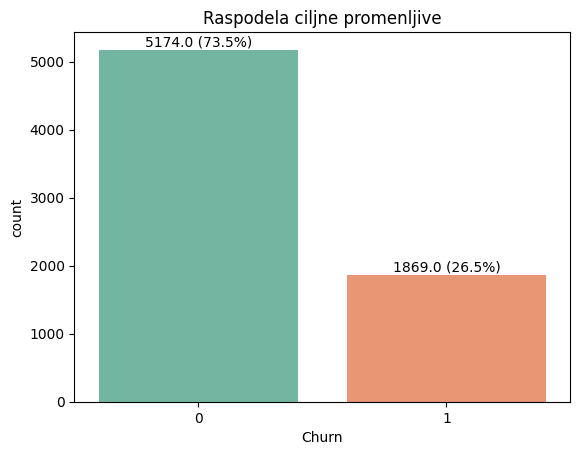

In [3]:
ax = sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)
total = len(df)
for p in ax.patches:
    ax.annotate(f'{p.get_height()} ({p.get_height()/total*100:.1f}%)', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.title('Raspodela ciljne promenljive')
plt.savefig('../reports/figures/01_churn_balans.png', dpi=150, bbox_inches='tight')
plt.show()

- Vidi se class imbalance

In [4]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [5]:
df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].agg(['mean', 'std']).round(2)

tenure        MonthlyCharges        TotalCharges         
        mean    std           mean    std         mean      std
Churn                                                          
0      37.57  24.11          61.27  31.09      2549.91  2329.95
1      17.98  19.53          74.44  24.67      1531.80  1890.82

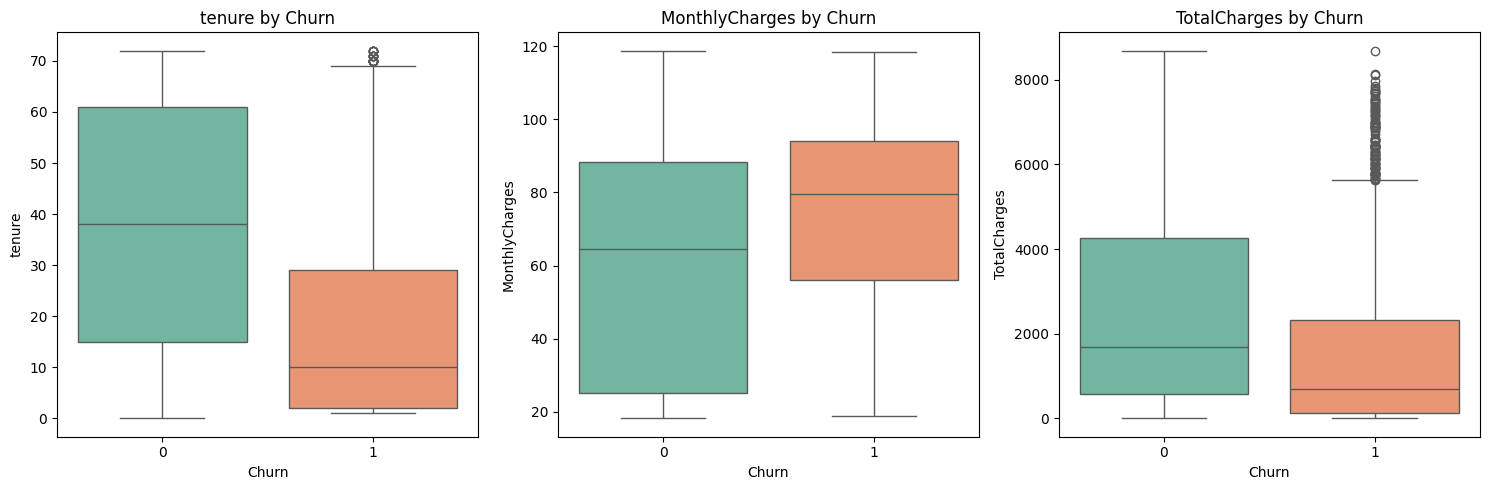

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.boxplot(data=df, x='Churn', y=col, ax=ax, 
                hue='Churn', palette='Set2', legend=False)
    ax.set_title(f'{col} by Churn')
plt.tight_layout()
plt.savefig('../reports/figures/02_boxplot_numericki.png', dpi=150, bbox_inches='tight')
plt.show()

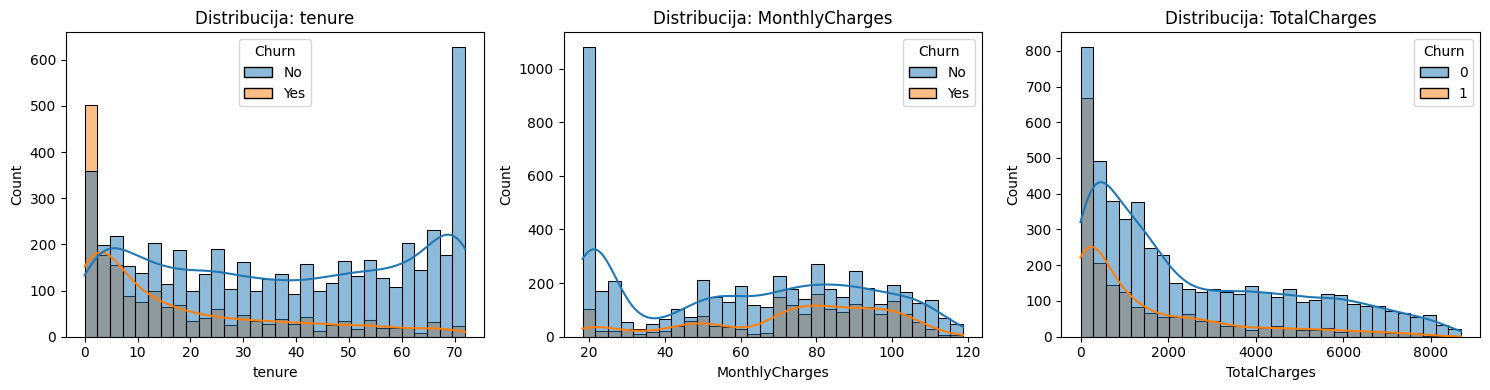

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# tenure i MonthlyCharges iz df_raw (ima string Churn za legendu)
for ax, col in zip(axes[:2], ['tenure', 'MonthlyCharges']):
    sns.histplot(data=df_raw, x=col, hue='Churn', kde=True, ax=ax, bins=30)
    ax.set_title(f'Distribucija: {col}')

# TotalCharges iz df (preprocessirani, TotalCharges je numericki)
sns.histplot(data=df, x='TotalCharges', hue='Churn', kde=True, ax=axes[2], bins=30)
axes[2].set_title('Distribucija: TotalCharges')

plt.tight_layout()
plt.savefig('../reports/figures/03_distribucije_numericki.png', dpi=150, bbox_inches='tight')
plt.show()

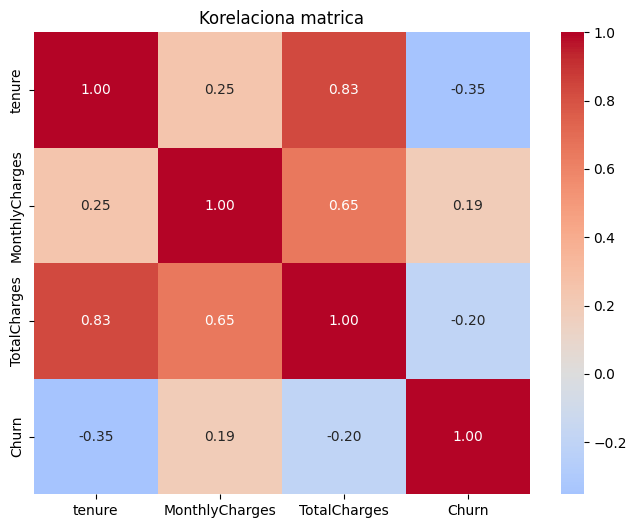

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr(), 
    annot=True, fmt='.2f', cmap='coolwarm', center=0
)
plt.title('Korelaciona matrica')
plt.savefig('../reports/figures/07_korelaciona_matrica.png', dpi=150, bbox_inches='tight')
plt.show()

tenure i TotalCharges → jaka pozitivna korelacija (duže ostaje = više platio)
tenure i Churn → negativna korelacija (duže ostaje = manja šansa da ode)
MonthlyCharges i Churn → slaba pozitivna (veći račun = malo veća šansa da ode)

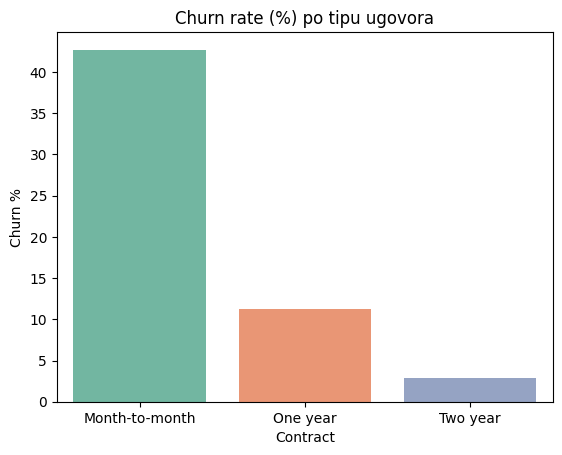

In [9]:
# Koristimo df_raw jer ima originalne string vrednosti
churn_rate = df_raw.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
churn_rate.columns = ['Contract', 'ChurnRate']

sns.barplot(data=churn_rate, x='Contract', y='ChurnRate', hue='Contract', palette='Set2', legend=False)
plt.title('Churn rate (%) po tipu ugovora')
plt.ylabel('Churn %')
plt.savefig('../reports/figures/04_churn_rate_contract.png', dpi=150, bbox_inches='tight')
plt.show()

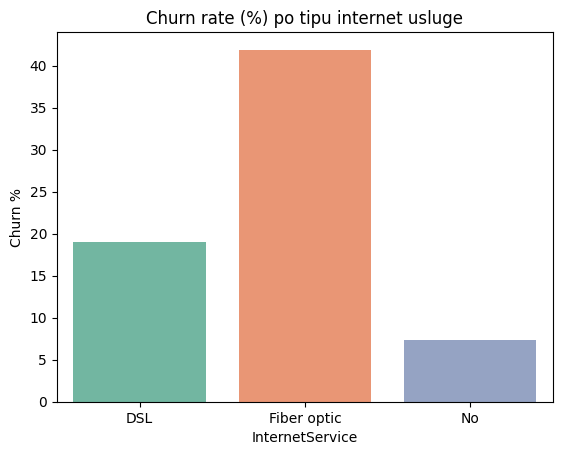

In [10]:
churn_rate = df_raw.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
churn_rate.columns = ['InternetService', 'ChurnRate']

sns.barplot(data=churn_rate, x='InternetService', y='ChurnRate', hue='InternetService', palette='Set2', legend=False)
plt.title('Churn rate (%) po tipu internet usluge')
plt.ylabel('Churn %')
plt.savefig('../reports/figures/05_churn_rate_internet.png', dpi=150, bbox_inches='tight')
plt.show()

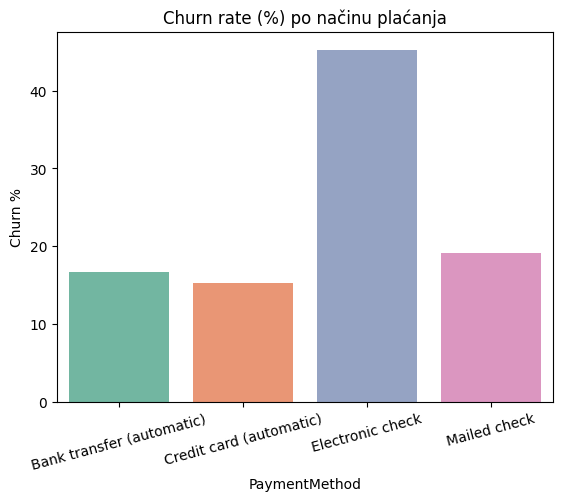

In [11]:
churn_rate = df_raw.groupby('PaymentMethod')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
churn_rate.columns = ['PaymentMethod', 'ChurnRate']

sns.barplot(data=churn_rate, x='PaymentMethod', y='ChurnRate', hue='PaymentMethod', palette='Set2', legend=False)
plt.title('Churn rate (%) po načinu plaćanja')
plt.ylabel('Churn %')
plt.xticks(rotation=15)
plt.savefig('../reports/figures/06_churn_rate_payment.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Odvajanje features (X) od ciljne promenljive (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# Podela na train i test set (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Churn u train setu: {y_train.mean():.2%}")
print(f"Churn u test setu: {y_test.mean():.2%}")

Train set: (5634, 26)
Test set: (1409, 26)
Churn u train setu: 26.54%
Churn u test setu: 26.54%


In [14]:
scaler = StandardScaler()

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("=== Logistička regresija ===")
print(classification_report(y_test, y_pred_lr))
print(f"AUC-ROC: {roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1]):.4f}")

=== Logistička regresija ===
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

AUC-ROC: 0.8418


In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print(f"AUC-ROC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.86      0.81      0.84      1035
           1       0.55      0.63      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409

AUC-ROC: 0.8217


In [17]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, 
                     scale_pos_weight=5174/1869,  # kompenzacija za imbalanced dataset
                     eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print(f"AUC-ROC: {roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]):.4f}")

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1035
           1       0.54      0.68      0.60       374

    accuracy                           0.76      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.76      0.77      1409

AUC-ROC: 0.8197


In [18]:
from sklearn.model_selection import GridSearchCV

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    rf_params,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print(f"Najbolji parametri: {rf_grid.best_params_}")
print(f"Najbolji F1 na CV: {rf_grid.best_score_:.4f}")

y_pred_rf_best = rf_grid.best_estimator_.predict(X_test)
print("\n=== Random Forest (tuned) ===")
print(classification_report(y_test, y_pred_rf_best))
print(f"AUC-ROC: {roc_auc_score(y_test, rf_grid.best_estimator_.predict_proba(X_test)[:, 1]):.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Najbolji parametri: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Najbolji F1 na CV: 0.6376

=== Random Forest (tuned) ===
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409

AUC-ROC: 0.8413


In [19]:
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(scale_pos_weight=5174/1869, random_state=42, eval_metric='logloss'),
    xgb_params,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print(f"Najbolji parametri: {xgb_grid.best_params_}")
print(f"Najbolji F1 na CV: {xgb_grid.best_score_:.4f}")

y_pred_xgb_best = xgb_grid.best_estimator_.predict(X_test)
print("\n=== XGBoost (tuned) ===")
print(classification_report(y_test, y_pred_xgb_best))
print(f"AUC-ROC: {roc_auc_score(y_test, xgb_grid.best_estimator_.predict_proba(X_test)[:, 1]):.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Najbolji parametri: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Najbolji F1 na CV: 0.6330

=== XGBoost (tuned) ===
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

AUC-ROC: 0.8448


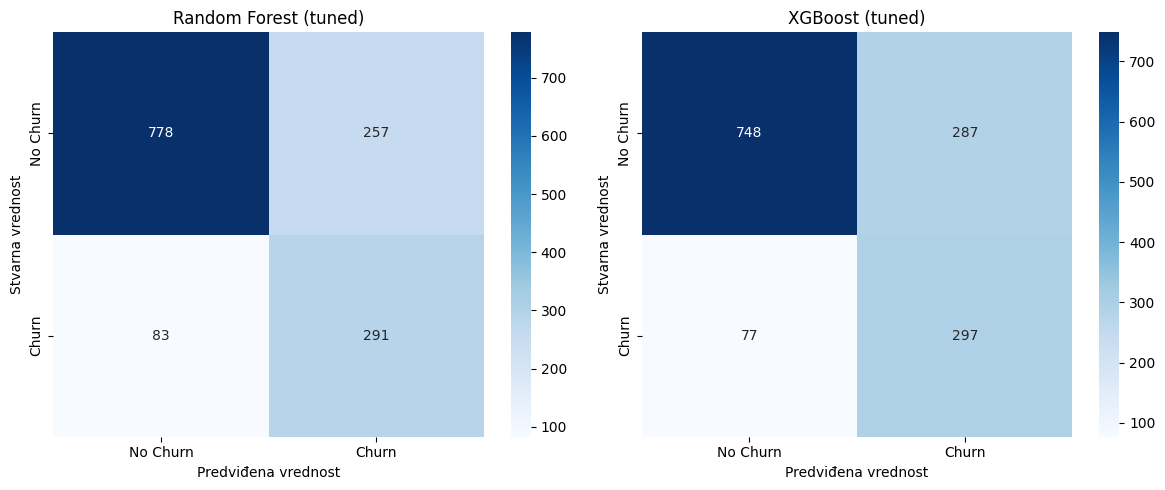

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = {
    'Random Forest (tuned)': y_pred_rf_best,
    'XGBoost (tuned)': y_pred_xgb_best
}

for ax, (name, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(name)
    ax.set_ylabel('Stvarna vrednost')
    ax.set_xlabel('Predviđena vrednost')

plt.tight_layout()
plt.savefig('../reports/figures/08_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

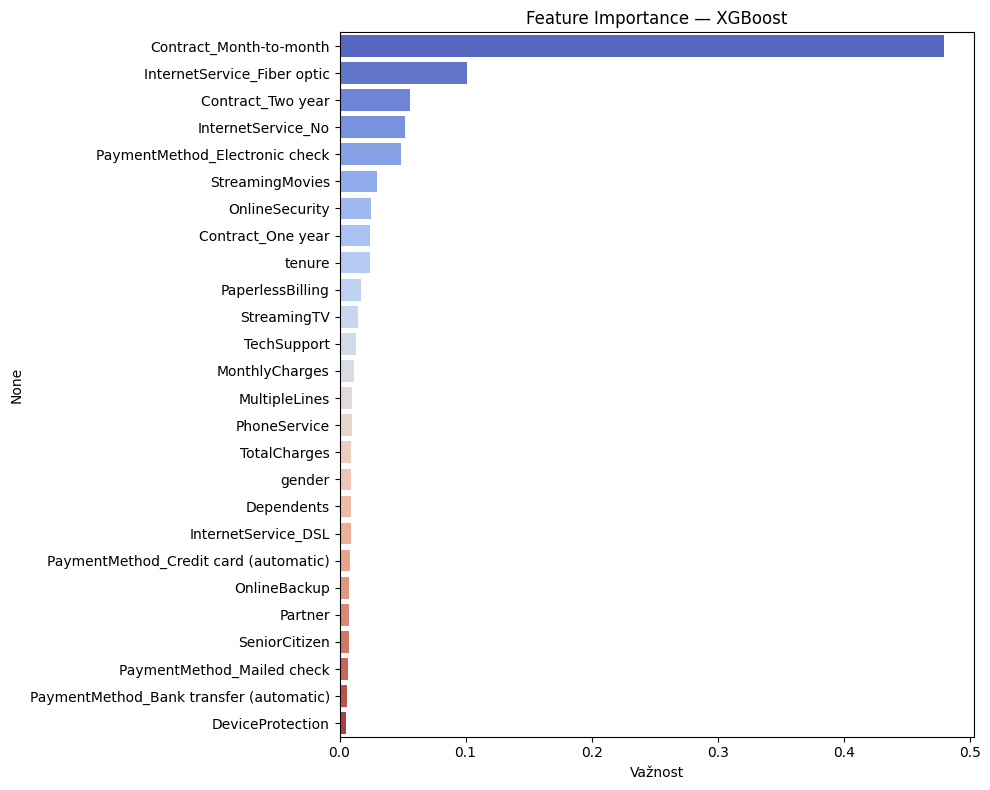

Contract_Month-to-month                    0.479212
InternetService_Fiber optic                0.101255
Contract_Two year                          0.056059
InternetService_No                         0.052290
PaymentMethod_Electronic check             0.048646
StreamingMovies                            0.029389
OnlineSecurity                             0.024941
Contract_One year                          0.024243
tenure                                     0.023844
PaperlessBilling                           0.017363
StreamingTV                                0.014345
TechSupport                                0.012694
MonthlyCharges                             0.011406
MultipleLines                              0.010201
PhoneService                               0.009533
TotalCharges                               0.009480
gender                                     0.009434
Dependents                                 0.008783
InternetService_DSL                        0.008738
PaymentMetho

In [21]:
feature_names = X_train.columns.tolist()
importances = xgb_grid.best_estimator_.feature_importances_

# Sortiraj po važnosti
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=feat_imp.values, y=feat_imp.index, hue=feat_imp.index, palette='coolwarm', legend=False)
plt.title('Feature Importance — XGBoost')
plt.xlabel('Važnost')
plt.tight_layout()
plt.savefig('../reports/figures/09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(feat_imp)

In [22]:
# Uzimamo atribute sa važnošću većom od 0.02
top_features = feat_imp[feat_imp > 0.02].index.tolist()
print(f"Odabrani atributi ({len(top_features)}):")
print(top_features)

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

Odabrani atributi (9):
['Contract_Month-to-month', 'InternetService_Fiber optic', 'Contract_Two year', 'InternetService_No', 'PaymentMethod_Electronic check', 'StreamingMovies', 'OnlineSecurity', 'Contract_One year', 'tenure']


In [23]:
xgb_top = XGBClassifier(
    scale_pos_weight=5174/1869,
    random_state=42,
    eval_metric='logloss',
    learning_rate=0.1,
    max_depth=3,
    n_estimators=100,
    subsample=0.8
)

xgb_top.fit(X_train_top, y_train)
y_pred_xgb_top = xgb_top.predict(X_test_top)

print("=== XGBoost (samo važni atributi) ===")
print(classification_report(y_test, y_pred_xgb_top))
print(f"AUC-ROC: {roc_auc_score(y_test, xgb_top.predict_proba(X_test_top)[:, 1]):.4f}")

=== XGBoost (samo važni atributi) ===
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

AUC-ROC: 0.8426


In [24]:
print("=== Poređenje ===")
print("XGBoost (svi atributi)    — AUC-ROC: 0.8448")
print(f"XGBoost (važni atributi)  — AUC-ROC: {roc_auc_score(y_test, xgb_top.predict_proba(X_test_top)[:, 1]):.4f}")

=== Poređenje ===
XGBoost (svi atributi)    — AUC-ROC: 0.8448
XGBoost (važni atributi)  — AUC-ROC: 0.8426


In [26]:
df.to_csv('../data/processed/telco_data_processed.csv', index=False)
print("Processed podaci sačuvani!")

Processed podaci sačuvani!


In [27]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("=== SVM ===")
print(classification_report(y_test, y_pred_svm))
print(f"AUC-ROC: {roc_auc_score(y_test, svm.predict_proba(X_test)[:, 1]):.4f}")

c:\Users\Dimitrije\Desktop\SAUSAU projekat\Projekat\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


=== SVM ===
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

AUC-ROC: 0.8250


In [30]:
svm_linear = SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42)
svm_linear.fit(X_train, y_train)

y_pred_svm_lin = svm_linear.predict(X_test)

print("=== SVM (Linear) ===")
print(classification_report(y_test, y_pred_svm_lin))
print(f"AUC-ROC: {roc_auc_score(y_test, svm_linear.predict_proba(X_test)[:, 1]):.4f}")

c:\Users\Dimitrije\Desktop\SAUSAU projekat\Projekat\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


=== SVM (Linear) ===
              precision    recall  f1-score   support

           0       0.91      0.65      0.76      1035
           1       0.46      0.82      0.59       374

    accuracy                           0.69      1409
   macro avg       0.68      0.73      0.67      1409
weighted avg       0.79      0.69      0.71      1409

AUC-ROC: 0.7927


In [32]:
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(
    SVC(class_weight='balanced', probability=True, random_state=42),
    svm_params,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train, y_train)

print(f"Najbolji parametri: {svm_grid.best_params_}")
print(f"Najbolji F1 na CV: {svm_grid.best_score_:.4f}")

y_pred_svm_best = svm_grid.best_estimator_.predict(X_test)
print("\n=== SVM (tuned) ===")
print(classification_report(y_test, y_pred_svm_best))
print(f"AUC-ROC: {roc_auc_score(y_test, svm_grid.best_estimator_.predict_proba(X_test)[:, 1]):.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits


c:\Users\Dimitrije\Desktop\SAUSAU projekat\Projekat\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Najbolji parametri: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Najbolji F1 na CV: 0.6228

=== SVM (tuned) ===
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

AUC-ROC: 0.8326


In [33]:
import joblib

# Scaler
joblib.dump(scaler, '../models/scaler.pkl')

# Logistička regresija
joblib.dump(lr, '../models/lr_model.pkl')

# Random Forest (default)
joblib.dump(rf, '../models/rf_model.pkl')

# XGBoost (default)
joblib.dump(xgb, '../models/xgb_model_default.pkl')

# Random Forest (tuned)
joblib.dump(rf_grid.best_estimator_, '../models/rf_model_tuned.pkl')

# XGBoost (tuned)
joblib.dump(xgb_top, '../models/xgb_model.pkl')

# SVM (linear kernel)
joblib.dump(svm_linear, '../models/svm_linear_kernel_model.pkl')

# SVM (tuned)
joblib.dump(svm_grid.best_estimator_, '../models/svm_model_tuned.pkl')

print("Svi modeli exportovani!")

Svi modeli exportovani!
